<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/social_media/Final_tweet_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Kwanda Mazibuko** - stdnr: 1077167

# **Importing Libraries**

In [1]:
!pip install -q tweepy gensim python-louvain

In [2]:
# Importing Libraries - make sure the packages are installed
import os
import tweepy as tw
import re
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import BytesIO

import networkx as nx
import community as community_louvain
from community.community_louvain import best_partition

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords


from gensim import corpora, models
from nltk.corpus import stopwords
import string
from nltk.tokenize import word_tokenize

import warnings
warnings.filterwarnings("ignore")

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **Loading Data**

In [3]:
# Reading data
%%time
FILE_ID = "1lhoPhOLB4fm-IgXlKhZFfC0UiFfHSklZ"
xlsx_url = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"
r = requests.get(xlsx_url)
df_1 = pd.read_excel(BytesIO(r.content), engine = "openpyxl")


CPU times: user 1min 47s, sys: 753 ms, total: 1min 48s
Wall time: 2min 1s


In [4]:
df_1.head(1)

,Query Id,Query Name,Date,Title,Url,Domain,Sentiment,Page Type,Language,Country Code,Continent Code,Continent,Country,City Code,Account Type,Added,Assignment,Author,Category Details,Checked,City,Display URLs,Entity Info,Expanded URLs,Facebook Author ID,Facebook Comments,Facebook Likes,Facebook Role,Facebook Shares,Facebook Subtype,Full Name,Full Text,Gender,Impressions,Instagram Comments,Instagram Followers,Instagram Following,Instagram Interactions Count,Instagram Posts,Interest,Last Assignment Date,Latitude,Location Name,Longitude,Media Filter,Media URLs,Mentioned Authors,Original Url,Priority,Professions,Resource Id,Short URLs,Starred,Station Name,Viewership,Status,Subtype,Thread Author,Thread Created Date,Thread Entry Type,Thread Id,Thread URL,Total Monthly Visitors,X Author ID,X Channel Role,X Followers,X Following,X Replies,X Reply to,X Repost of,X Reposts,X Likes,X Posts,X Verified,Updated,Reach (new),Publication Name,Licenses,Redacted,Redacted Fields,Redaction Reason,Asset Content Id,Asset Thumb Id,Author Verified Type,Avatar,Batch Id,Blog Name,Broadcast Media Url,Is Syndicated,Air Type,Broadcast Type,Media Type,Ad Value,Circulation,Region,Region Code,Daily Visitors,Engagement Type,Hashtags,Item Review,Kicker,Linkedin Comments,Linkedin Engagement,Linkedin Impressions,Linkedin Likes,Linkedin Shares,Linkedin Sponsored,Linkedin Video Views,Parent Post Id,Parent Blog Name,Pub Type,Publisher Sub Type,Rating,Reddit Score,Reddit Score Upvote Ratio,Reddit Comments,Reddit Author Karma,Root Post Id,Root Blog Name,Subreddit,Subreddit Subscribers,Subscriptions,Sub Title,React Score Overall,React Score Emotionality,React Score Harmful,Engagement Score,Subreddit NSFW,Reddit Post Flair,Reddit Author Flair,Subreddit Topics,Reddit Spoiler,Publication Id,Page Type Name,Content Source,Content Source Name,Custom,Bluesky Author Id,Bluesky Followers,Bluesky Following,Bluesky Likes,Bluesky Posts,Bluesky Quotes,Bluesky Replies,Bluesky Reposts,Can Edit Markup,Can Edit Metadata,Can Edit Segmentation,Can Edit Workflow,Copyright,Factiva Attribute Code,Has Full Text,Impact,Instagram Likes,Mention Id,Podcast Audience Estimate,Podcast Duration Ms,Raw Metadata,Reportable,Threads Likes,Threads Quotes,Threads Replies,Threads Reposts,Threads Shares,Threads Views,Tiktok Comments,Tiktok Connected Account,Tiktok Likes,Tiktok Reach,Tiktok Shares,Tiktok Views,Weblog Title,Youtube Comments,Youtube Duration Milliseconds,Youtube Favourites,Youtube Likes,Youtube Subscriber Count,Youtube Video Count,Emotion
0,2003594270,Kenya protests 2025,2025-08-31 21:59:50.0,RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no escape route for the wicked!\n\n#DualeMustGo #RutoMustGo #DrainTheSwamp,http://twitter.com/kelvinngari62/statuses/1962274155270635732,twitter.com,negative,twitter,en,KEN,AFRICA,Africa,Kenya,KEN.Coast.Mombasa,individual,2025-09-02T09:16:47.214+0000,NaN,kelvinngari62,NaN,False,Mombasa,NaN,"{entityId=13414952, entityConfidence=HIGH, url=https://www.wikidata.org/wiki/Q13414952}, {entityId=43169, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q43169}, {entityId=2727213, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q2727213}, {entityId=4682154, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q4682154}, {entityId=497, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q497}",NaN,NaN,0,0,NaN,0,NaN,kelvinngari62 (knn),RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no e

In [5]:
df_1.shape

(49823, 179)

#### **Pre-Processing**

In [6]:
# Changing column names
df_1.columns = df_1.columns.str.replace(' ', '_', regex=False).str.lower()

In [7]:
# Adding datetime
df_1['date'] = pd.to_datetime(df_1['date'])
df_june_2025 = df_1[(df_1['date'].dt.month == 6) & (df_1['date'].dt.year == 2025)]

# **Question One**





#### **a. (i) User-Mention Network**

**Nodes** will be authors and mentioned users, and **edges** will go from an author to a mentioned user.


In [8]:
# Function to extract mentions from full_text (re-included from cell 297c898e)
def extract_mentions(text):
    mentions = re.findall(r'@(\w+)', str(text))
    return list(set(mentions))

# Add mentions and tweet_author
df_june_2025['tweet_author'] = df_june_2025['author']
df_june_2025['mentions'] = df_june_2025['full_text'].apply(extract_mentions)

# Add graph
G_mentions = nx.DiGraph()
for index, row in df_june_2025.iterrows():
    author = row['tweet_author']

    mentions = row['mentions']
    if author not in G_mentions:
        G_mentions.add_node(author)

    if mentions:
        for mentioned_user in mentions:
            if mentioned_user not in G_mentions:
                G_mentions.add_node(mentioned_user)
            G_mentions.add_edge(author, mentioned_user)

print(f"Number of nodes in G_mentions: {G_mentions.number_of_nodes()}")
print(f"Number of edges in G_mentions: {G_mentions.number_of_edges()}")

Number of nodes in G_mentions: 14452
Number of edges in G_mentions: 33555


**User-Mention Network Metrics**

 - Calculate degree centrality, betweenness centrality, and clustering coefficient.

In [11]:
%%time
# Calculate Degree Centrality
degree_centrality = nx.degree_centrality(G_mentions)

# Calculate Betweenness
betweenness_centrality = nx.betweenness_centrality(G_mentions)

# Calculate Clustering Coefficient
clustering_coefficient = nx.clustering(G_mentions)

# Filter out nodes with 0 clustering coefficient
meaningful_clustering = {node: coeff for node, coeff in clustering_coefficient.items() if coeff > 0}


CPU times: user 8min 7s, sys: 353 ms, total: 8min 7s
Wall time: 8min 16s


##### **Top 15 Influencial Nodes**

In [12]:
print('')
print('Top 15 Influential Nodes by Degree Centrality')
# Sort degree_centrality in descending order and print top 15
sorted_degree_centrality = sorted(degree_centrality.items(), key = lambda item: item[1], reverse = True)
for node, centrality in sorted_degree_centrality[:15]:
    print(f"Node: {node}, Degree Centrality: {centrality:.4f}")

print('')
print('Top 15 Influential Nodes by Betweenness')
# Sort betweenness_centrality in descending order and print top 15
sorted_betweenness_centrality = sorted(betweenness_centrality.items(), key = lambda item: item[1], reverse = True)
for node, centrality in sorted_betweenness_centrality[:15]:
    print(f"Node: {node}, Betweenness Centrality: {centrality:.4f}")


Top 15 Influential Nodes by Degree Centrality
Node: IAMRAPCHA, Degree Centrality: 0.0540
Node: FGaitho237, Degree Centrality: 0.0453
Node: itskipronoh, Degree Centrality: 0.0441
Node: C_NyaKundiH, Degree Centrality: 0.0430
Node: Honeyfarsafi, Degree Centrality: 0.0367
Node: nickmuthumbi, Degree Centrality: 0.0352
Node: McKennaMK, Degree Centrality: 0.0314
Node: Ngartia, Degree Centrality: 0.0286
Node: WilliamsRuto, Degree Centrality: 0.0256
Node: _James041, Degree Centrality: 0.0224
Node: Nyandia_G, Degree Centrality: 0.0220
Node: MissMutukuT, Degree Centrality: 0.0219
Node: fit_ermined, Degree Centrality: 0.0217
Node: bevalynekwambo3, Degree Centrality: 0.0197
Node: sholard_mancity, Degree Centrality: 0.0192

Top 15 Influential Nodes by Betweenness
Node: C_NyaKundiH, Betweenness Centrality: 0.0005
Node: JaokooMoses, Betweenness Centrality: 0.0004
Node: Ngartia, Betweenness Centrality: 0.0004
Node: Eastlandspresi1, Betweenness Centrality: 0.0004
Node: justinewanda, Betweenness Central

- **User-Mention Network** - Top 15 by Degree Centrality: IAMRAPCHA, FGaitho237, itskipronoh, C_NyaKundiH, Honeyfarsafi, nickmuthumbi, McKennaMK, Ngartia, WilliamsRuto, _James041, Nyandia_G, MissMutukuT, fit_ermined, bevalynekwambo3, sholard_mancity

- **User-Mention Network** - Top 15 by Betweenness Centrality: C_NyaKundiH, JaokooMoses, Ngartia, Eastlandspresi1, justinewanda, mtunecessary, MugureNderitu, Honeyfarsafi, Kibet_bull, kamwari_, Femi_One, Maestropuns, BernardKavuli, Wycliffe_Otie, nickiBIGFISH


**User-Mention Network for Gephi**

In [13]:
# Add calculated metrics as node attributes to G_mentions (full graph)
for node, centrality in degree_centrality.items():
    G_mentions.nodes[node]['degree_centrality'] = centrality

for node, centrality in betweenness_centrality.items():
    G_mentions.nodes[node]['betweenness_centrality'] = centrality

for node, coeff in clustering_coefficient.items():
    G_mentions.nodes[node]['clustering_coefficient'] = coeff

# Identify top influential nodes for user-mention network
top_degree_nodes = {node for node, centrality in sorted_degree_centrality[:15]}
top_betweenness_nodes = {node for node, centrality in sorted_betweenness_centrality[:15]}

# Combine these sets to get all unique top influential nodes
influential_nodes_mentions = list(top_degree_nodes.union(top_betweenness_nodes))

# Create a subgraph with only these influential nodes and their connections
G_mentions_influential = G_mentions.subgraph(influential_nodes_mentions)

In [14]:
# Save the G_mentions_influential graph to a GEXF file
nx.write_gexf(G_mentions_influential, 'user_mention_network_top_influencers.gexf')
print('export successful')

export successful


#### **a. (ii) Retweet Network**

**Nodes** will be the authors of the original tweets and the authors who retweeted them, and **edges** will go from the retweeting user to the retweeted user.


In [15]:
# Function to extract retweeted author
def extract_retweet_author(text):
    retweet_match = re.match(r'RT @(\w+)', str(text))
    if retweet_match:
        return retweet_match.group(1)
    return None

# Adding 'retweeted_author' column
df_june_2025['retweeted_author'] = df_june_2025['full_text'].apply(extract_retweet_author)

# Graph
G_retweets = nx.DiGraph()
for index, row in df_june_2025.iterrows():
    retweeter = row['tweet_author']
    retweeted = row['retweeted_author']

    if retweeter not in G_retweets:
        G_retweets.add_node(retweeter)

    if retweeted:
        if retweeted not in G_retweets:
            G_retweets.add_node(retweeted)
        G_retweets.add_edge(retweeter, retweeted)

# 6. Print the total number of nodes and edges
print(f"Number of nodes in G_retweets: {G_retweets.number_of_nodes()}")
print(f"Number of edges in G_retweets: {G_retweets.number_of_edges()}")

Number of nodes in G_retweets: 13875
Number of edges in G_retweets: 28869


**Retweets Network Metrics**

 - Calculate degree centrality, betweenness , and clustering coefficient.

In [18]:
%%time
# Calculate Degree Centrality
degree_centrality_retweets = nx.degree_centrality(G_retweets)

# Calculate Betweenness
betweenness_centrality_retweets = nx.betweenness_centrality(G_retweets)

# Calculate Clustering Coefficient
clustering_coefficient_retweets = nx.clustering(G_retweets)

# Filter out nodes with 0 clustering coefficient
meaningful_clustering_retweets = {node: coeff for node, coeff in clustering_coefficient_retweets.items() if coeff > 0}

CPU times: user 7min 7s, sys: 314 ms, total: 7min 7s
Wall time: 7min 10s


##### **Top 15 Influencial Nodes**

In [19]:
print()
print('Top 15 Influential Nodes by Degree Centrality (Retweets)')
# Sort degree_centrality_retweets in descending order and print top 15
sorted_degree_centrality_retweets = sorted(degree_centrality_retweets.items(), key = lambda item: item[1], reverse = True)
for node, centrality in sorted_degree_centrality_retweets[:15]:
    print(f"Node: {node}, Degree Centrality: {centrality:.4f}")

print('')
print('Top 15 Influential Nodes by Betweenness (Retweets)')
# Sort betweenness_centrality_retweets in descending order and print top 15
sorted_betweenness_centrality_retweets = sorted(betweenness_centrality_retweets.items(), key = lambda item: item[1], reverse = True)
for node, centrality in sorted_betweenness_centrality_retweets[:15]:
    print(f"Node: {node}, Betweenness Centrality: {centrality:.4f}")


Top 15 Influential Nodes by Degree Centrality (Retweets)
Node: IAMRAPCHA, Degree Centrality: 0.0553
Node: itskipronoh, Degree Centrality: 0.0454
Node: FGaitho237, Degree Centrality: 0.0452
Node: C_NyaKundiH, Degree Centrality: 0.0388
Node: nickmuthumbi, Degree Centrality: 0.0365
Node: McKennaMK, Degree Centrality: 0.0325
Node: Ngartia, Degree Centrality: 0.0294
Node: Nyandia_G, Degree Centrality: 0.0227
Node: MissMutukuT, Degree Centrality: 0.0226
Node: _James041, Degree Centrality: 0.0205
Node: Honeyfarsafi, Degree Centrality: 0.0204
Node: sholard_mancity, Degree Centrality: 0.0198
Node: fit_ermined, Degree Centrality: 0.0198
Node: bevalynekwambo3, Degree Centrality: 0.0195
Node: Kimuzi_, Degree Centrality: 0.0163

Top 15 Influential Nodes by Betweenness (Retweets)
Node: kamwari_, Betweenness Centrality: 0.0002
Node: Ngartia, Betweenness Centrality: 0.0002
Node: C_NyaKundiH, Betweenness Centrality: 0.0002
Node: Femi_One, Betweenness Centrality: 0.0002
Node: mtunecessary, Betweenness 

- **Retweet Network** - Top 15 by Degree Centrality: IAMRAPCHA, itskipronoh, FGaitho237, C_NyaKundiH, nickmuthumbi, McKennaMK, Ngartia, Nyandia_G, MissMutukuT, James041, Honeyfarsafi, sholard_mancity, fit_ermined, bevalynekwambo3, Kimuzi

- **Retweet Network** - Top 15 by Betweenness Centrality: kamwari_, Ngartia, C_NyaKundiH, Femi_One, mtunecessary, justinewanda, MugureNderitu, omalicha, Kibet_bull, JaokooMoses, Honeyfarsafi, Eastlandspresi1, Maestropuns, epicstevens, Wycliffe_Otie

**Retweet Network for Gephi**

In [20]:
# Add calculated metrics as node attributes to G_retweets
for node, centrality in degree_centrality_retweets.items():
    G_retweets.nodes[node]['degree_centrality'] = centrality

for node, centrality in betweenness_centrality_retweets.items():
    G_retweets.nodes[node]['betweenness_centrality'] = centrality

for node, coeff in clustering_coefficient_retweets.items():
    G_retweets.nodes[node]['clustering_coefficient'] = coeff

# Identify top influential nodes for retweet network
top_degree_nodes_retweets = {node for node, centrality in sorted_degree_centrality_retweets[:15]}
top_betweenness_nodes_retweets = {node for node, centrality in sorted_betweenness_centrality_retweets[:15]}

# Combine these sets to get all unique top influential nodes
influential_nodes_retweets = list(top_degree_nodes_retweets.union(top_betweenness_nodes_retweets))

# Create a subgraph with only these influential nodes and their connections
G_retweets_influential = G_retweets.subgraph(influential_nodes_retweets)


In [21]:
# Save the G_retweets_influential graph to a GEXF file
nx.write_gexf(G_retweets_influential, 'retweet_network_top_influencers.gexf')
print('export successful')

export successful


#### **b. Interpretation**


The network analysis of the 'Kenya protests 2025' conversation reveals a tightly interconnected structure dominated by a small group of highly influential users. Central to both the user-mention and retweet networks are individuals like IAMRAPCHA, FGaitho237, itskipronoh, C_NyaKundiH, and Ngartia, who consistently rank high in both degree and betweenness centrality. IAMRAPCHA, in particular, stands out for exceptional visibility, topping degree centrality in both networks, indicating frequent mentions and retweets. C_NyaKundiH and Ngartia are especially notable for their high betweenness centrality, marking them as key brokers who bridge otherwise disconnected clusters, facilitating the flow of information across the network.

The distinction between influence through mentions and retweets is critical. In the mention network, high degree centrality reflects direct engagement—users are either frequently mentioned or actively mention others—while high betweenness centrality indicates a role in connecting different conversational groups. In contrast, the retweet network highlights users whose content is widely disseminated or who actively amplify others’ messages. Here, users like kamwari_ and Femi_One emerge as important bridges, even if they are not the most visible.

Overall, the analysis underscores a communication ecosystem where a few nodes play outsized roles in shaping discourse. These users not only drive visibility but also serve as conduits for information, enabling rapid dissemination and cross-group engagement. Their influence likely extends beyond visibility to shaping sentiment and mobilization, especially during critical protest moments. The presence of such centralized influence structures suggests that narratives around the protests are significantly shaped by a handful of actors, making them pivotal in both amplifying calls to action and diffusing counter-narratives. Understanding these dynamics is essential for grasping how digital activism and public discourse evolve in high-stakes sociopolitical contexts.


# **Question Two**

In [22]:
# custom stop words
custom_stopwords = {
    'sirininumbers', 'genz', 'genzpower', 'genzmovement'
, 'genzforchange', 'rutosmustgo', 'rejectfinancebill', 'kenyaprotests'
, 'kenyagenz', 'justiceforalbert',
'protest', 'march', 'demonstration',
'rally', 'mobilize', 'backlash', 'activist', 'movement', 'streets'
, 'chant', 'placard', 'crowd', 'solidarity'
'nairobi', 'mombasa', 'kisumu', 'nakuru', 'eldoret', 'nyeri', 'kenya'
,'government', 'president', 'ruto', 'bill', 'finance'
, 'tax', 'parliament', 'police', 'brutality', 'justice'
, 'change', 'freedom','rt','RT','retweet', 'share', 'follow', 'thread', 'viral', 'trend'
, 'post', 'comment', 'like', 'x', 'twitter','dci'
}

#stop words
nltk_stopwords = set(stopwords.words('english'))
all_stopwords = nltk_stopwords.union(custom_stopwords)


def clean_tweet(text):
    if pd.isnull(text):
        return ""

    # Remove mentions, hashtags, URLs, RTs
    text = re.sub(r'@[_\w]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\brt\b', '', text, flags=re.IGNORECASE)

    # Remove numbers and punctuation
    text = re.sub(r'\\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Lowercase and tokenize
    tokens = word_tokenize(text.lower())

    # Remove all stopwords and short tokens
    tokens = [word for word in tokens if word not in all_stopwords and len(word) > 2]

    return ' '.join(tokens)

In [23]:
# New Dataframe - Entire tweets
df = df_1.copy()
cols = ['date','full_text', 'sentiment', 'emotion', 'author']
df_2 = df[cols]

In [24]:
# Adding clean tweet call
df_2['clean_tweet'] = df_2['full_text'].apply(clean_tweet)

# Adding week feature
df_2['week'] = df_2['date'].dt.to_period('W').apply(lambda r: r.start_time)
df_2.head(1)

,date,full_text,sentiment,emotion,author,clean_tweet,week
0,2025-08-31 21:59:50,RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no escape route for the wicked!\n\n#DualeMustGo #RutoMustGo #DrainTheSwamp,negative,Sadness,kelvinngari62,aden duale guilty guy tried ethical card failed sha theft affected everyone one wants associated thief tried hiring affordable bloggers humbled truth crocodile smiles anus widens theres escape route wicked,2025-08-25


Sentiment Analysis Over Time

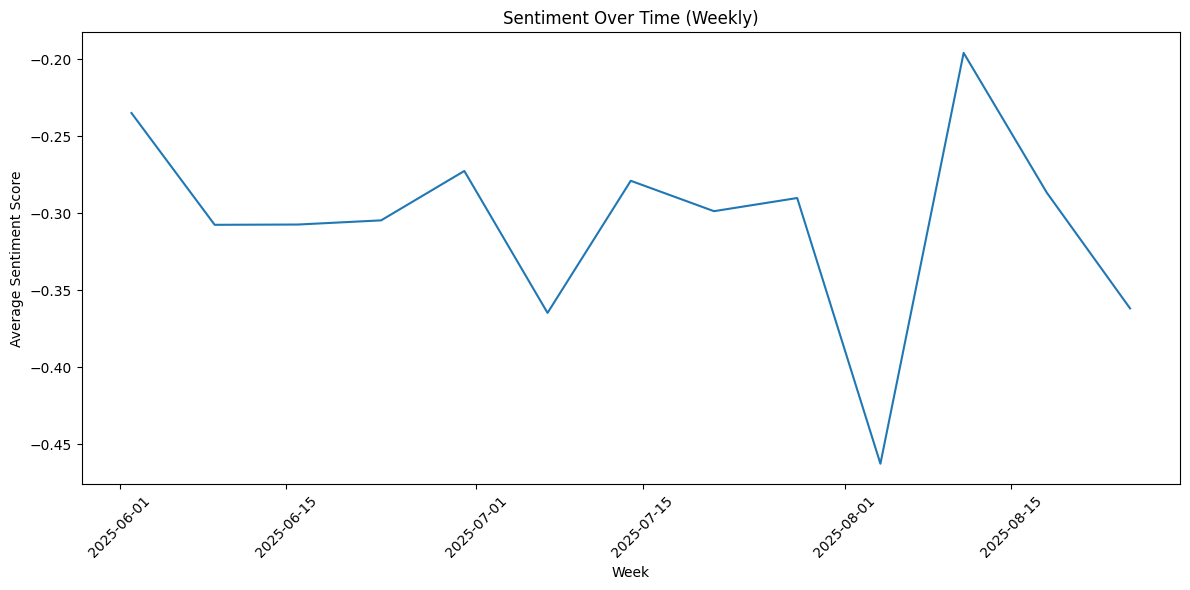

In [25]:
# Map sentiment to numerical values
sentiment_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
df_2['sentiment_score'] = df_2['sentiment'].map(sentiment_mapping)

# Aggregate sentiment scores weekly
sentiment_weekly = df_2.groupby('week')['sentiment_score'].mean().reset_index()

# Plot sentiment trend
plt.figure(figsize=(12,6))
sns.lineplot(data = sentiment_weekly, x = 'week', y = 'sentiment_score')
plt.title('Sentiment Over Time (Weekly)')
plt.xlabel('Week')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Emotion Peak Detection

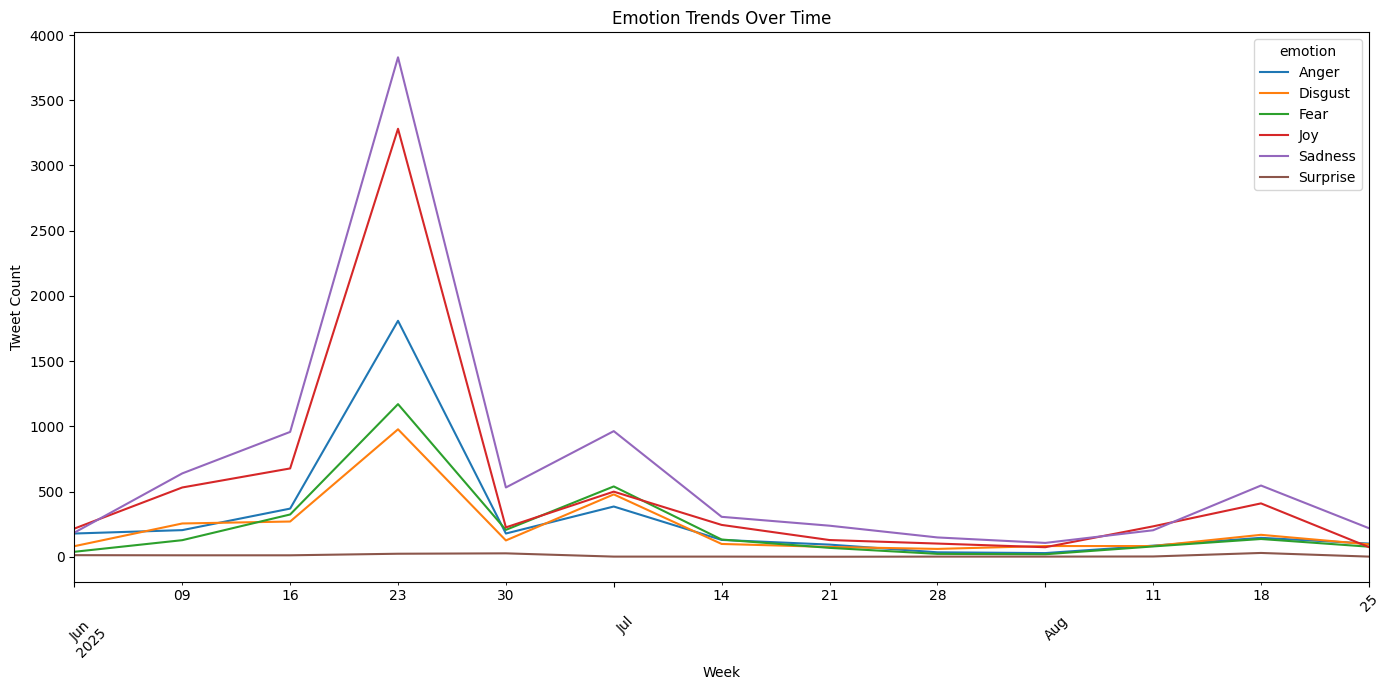

In [26]:
# Count emotions weekly
emotion_weekly = df_2.groupby(['week', 'emotion']).size().unstack(fill_value = 0)

# Plot emotional rhythms
emotion_weekly.plot(figsize = (14,7), title = 'Emotion Trends Over Time')
plt.xlabel('Week')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
%%time
stop_words = all_stopwords

def preprocess(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in stop_words]

# Weekly topic modeling
weekly_topics = {}
for week, group in df_2.groupby('week'):
    texts = group['clean_tweet'].dropna().apply(preprocess).tolist()
    if len(texts) < 10: continue  # skip sparse weeks
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    lda = models.LdaModel(corpus, num_topics = 3, id2word = dictionary, passes = 10)
    topics = lda.print_topics()
    weekly_topics[week] = topics

CPU times: user 2min 20s, sys: 162 ms, total: 2min 21s
Wall time: 2min 25s


In [28]:
# Identify weeks with highest anger or lowest sentiment
peak_anger = emotion_weekly['Anger'].idxmax()
lowest_sentiment = sentiment_weekly.loc[sentiment_weekly['sentiment_score'].idxmin(), 'week']

print(f"Peak anger week: {peak_anger}")
print(f"Lowest sentiment week: {lowest_sentiment}")

Peak anger week: 2025-06-23 00:00:00
Lowest sentiment week: 2025-08-04 00:00:00


Weekly Topic

In [29]:
print("Weekly Topic Insights")
for week, topics_list in weekly_topics.items():
    print(f"\nWeek: {week}")

    # Highlight peak anger and lowest sentiment weeks
    if week == peak_anger:
        print('NB: This is the PEAK ANGER week')
    if week == lowest_sentiment:
        print('NB: This is the LOWEST SENTIMENT week')

    for i, topic in enumerate(topics_list):
        # Extract keywords from the string
        keywords = re.findall(r'"(.*?)"', topic[1])
        print(f"  Topic {i+1}: {', '.join(keywords)}")

Weekly Topic Insights

Week: 2025-06-02 00:00:00
  Topic 1: public, reject, people, participation, holiday, kenyans, arrested, education, must, guys
  Topic 2: maandamano, tomorrow, message, spread, must, enough, june, every, ill, kenyan
  Topic 3: albert, ojwang, killed, station, killing, country, central, blogger, officer, number

Week: 2025-06-09 00:00:00
  Topic 1: must, kenyans, maandamano, june, cant, time, business, kill, wantam, albert
  Topic 2: albert, ojwang, eliud, enough, killed, million, must, dig, widely, tweets
  Topic 3: dont, let, albert, kevin, kennedy, denis, ojwang, john, please, brian

Week: 2025-06-16 00:00:00
  Topic 1: must, free, kenyans, enough, man, lagat, arrested, yet, innocent, albert
  Topic 2: people, day, one, june, house, year, know, reading, kenyans, stand
  Topic 3: tuesday, total, shutdown, goons, execution, nairobi, moi, state, cbd, masks

Week: 2025-06-23 00:00:00
NB: This is the PEAK ANGER week
  Topic 1: wednesday, must, need, nairobi, cbd, roa